# Region Comparison
Compare two spatial regions of interest (ROI) across tissues: DE + enrichment analysis.

In [1]:
import anndata as ad
import pandas as pd
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import geopandas as gpd
from matplotlib.widgets import LassoSelector
from matplotlib.path import Path as MplPath
import ipympl
%matplotlib widget
import matplotlib
import spatialdata as spd
from spatialdata.transformations import get_transformation
from shapely.affinity import scale as shapely_scale
from shapely.geometry import Polygon
import scipy.sparse as sp
import gseapy as gp
from statsmodels.stats.multitest import multipletests


/home/janzules/mamba_envs/spatial_gpu_py311/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/janzules/mamba_envs/spatial_gpu_py311/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


In [2]:
import sys
_candidates = []
_nb = globals().get("__vsc_ipynb_file__")
if _nb:
    _candidates.append(Path(_nb).resolve().parent)
_candidates.append(Path.cwd().resolve())
_candidates.extend([
    Path("/home/janzules/spatial/CAR-T/code"),
    Path("/Users/janzules/Roselab/Spatial/CAR_T/code"),
])
_added = False
for _start in _candidates:
    for _parent in [_start, *_start.parents]:
        if (_parent / "misc" / "plot_style.py").exists():
            if str(_parent) not in sys.path:
                sys.path.insert(0, str(_parent))
            _added = True
            break
    if _added:
        break
if not _added:
    raise RuntimeError("Could not locate code/misc/plot_style.py")
from misc.plot_style import CELL_TYPE_COLORS, get_cell_colors


# Data Prep
## Locations
### Gemini

In [3]:
zarr_file   = "/coh_labs/yunroseli/Jona/CAR-T/data/zarr/fullDataset/processing_Zarr/1_C2l_annotated_CC"
code_folder = Path("/home/janzules/spatial/CAR-T/code")
project_dir = Path("/coh_labs/yunroseli/Jona/CAR-T/")


### Laptop

In [4]:
# project_dir = Path("/Users/janzules/Roselab/Spatial/CAR_T")
# zarr_file   = project_dir / "data/zarrFiles/CellCharterClusters"


## Loading Data

In [5]:
sdata = spd.read_zarr(zarr_file)
adata = sdata.tables['segmentation_counts']


KeyboardInterrupt: 

# Functions

In [ ]:
def read_gmt(gmt_path):
    gene_sets = {}
    rows = []
    with open(gmt_path, "r") as f:
        for line in f:
            parts = line.rstrip("\n").split("\t")
            if len(parts) < 3:
                continue
            gene_set    = parts[0]
            description = parts[1]
            genes       = parts[2:]
            gene_sets[gene_set] = genes
            rows.append({
                "gene_set":    gene_set,
                "description": description,
                "n_genes":     len(genes),
                "source_file": Path(gmt_path).name,
            })
    return gene_sets, pd.DataFrame(rows)


In [ ]:
pathway_dir = project_dir / "data/references/pathways"

gmt_files = {
    "hallmark": pathway_dir / "mh.all.v2026.1.Mm.symbols.gmt",
    "reactome": pathway_dir / "m2.cp.reactome.v2026.1.Mm.symbols.gmt",
    "go_bp":    pathway_dir / "m5.go.bp.v2026.1.Mm.symbols.gmt",
    "curated":  pathway_dir / "m2.cp.v2026.1.Mm.symbols.gmt",
}

all_gene_sets = {}
gene_set_metadata_list = []

for collection, path in gmt_files.items():
    gs, meta = read_gmt(path)
    meta["collection"] = collection
    all_gene_sets.update(gs)
    gene_set_metadata_list.append(meta)

gene_set_metadata = pd.concat(gene_set_metadata_list, ignore_index=True)
print(f"Total gene sets loaded: {len(all_gene_sets):,}")
display(gene_set_metadata.groupby("collection")[["gene_set"]].count())


Total gene sets loaded: 9,618


,gene_set
collection,
curated,1787
go_bp,7781
hallmark,50
reactome,1333


In [ ]:
def get_tissue_transform(sdata, tissue_name):
    """Returns (scale, tx, ty) for shapes → image pixel mapping."""
    shapes_key = f"{tissue_name}_cell_boundaries"
    image_key  = f"{tissue_name}_hires_tissue_image"
    cs = "downscale_to_hires"
    shapes_tf   = get_transformation(sdata.shapes[shapes_key], get_all=True)[cs]
    scale       = float(shapes_tf.scale[0])
    image_tf    = get_transformation(sdata.images[image_key], get_all=True)[cs]
    translation = image_tf.transformations[0].translation
    ty, tx      = float(translation[1]), float(translation[2])
    return scale, tx, ty


In [ ]:
def plot_tissue_for_selection(sdata, adata, tissue_name,
                              pathway_1=None, top_quantile=0.25,
                              cell_type_col=None, cell_types_to_show=None,
                              highlight_types=None, highlight_buffer=25,
                              he_alpha=0.6, shrink=1, col_1="Blues"):
    """
    Render a tissue for interactive lasso selection.
    Returns (fig, ax, a_sub, coords_shared, scale) for use by the selector cell.
    """
    from matplotlib.patches import Patch

    cell_types_to_show = cell_types_to_show or []
    highlight_types    = highlight_types or []

    image_key    = f"{tissue_name}_hires_tissue_image"
    boundary_key = f"{tissue_name}_cell_boundaries"

    image  = sdata.images[image_key].values
    shapes = sdata.shapes[boundary_key].copy()

    shapes["geometry"] = shapes["geometry"].convex_hull.buffer(-shrink)
    scale, tx, ty = get_tissue_transform(sdata, tissue_name)
    shapes["geometry"] = shapes["geometry"].apply(
        lambda geom: shapely_scale(geom, xfact=scale, yfact=scale, origin=(0, 0))
    )

    mask  = adata.obs["tissue"] == tissue_name
    a_sub = adata[mask]

    join_cols = [c for c in [pathway_1, cell_type_col] if c is not None
                 and c in a_sub.obs.columns]
    shapes = shapes.join(a_sub.obs[join_cols], how="left")

    # Filtering
    if cell_type_col and cell_types_to_show:
        threshold    = shapes[pathway_1].quantile(1 - top_quantile) if pathway_1 else None
        shapes_other = shapes[
            (shapes[pathway_1] >= threshold) &
            (~shapes[cell_type_col].isin(cell_types_to_show))
        ].dropna(subset=[pathway_1]).copy() if pathway_1 else shapes[
            ~shapes[cell_type_col].isin(cell_types_to_show)].copy()
        shapes_ct_normal  = shapes[
            shapes[cell_type_col].isin(cell_types_to_show) &
            ~shapes[cell_type_col].isin(highlight_types)].copy()
        shapes_highlight  = shapes[shapes[cell_type_col].isin(highlight_types)].copy()
        shapes_highlight["geometry"] = shapes_highlight["geometry"].buffer(highlight_buffer)
    elif pathway_1:
        threshold  = shapes[pathway_1].quantile(1 - top_quantile)
        shapes_other = shapes[shapes[pathway_1] >= threshold].copy()
        shapes_ct_normal = shapes_highlight = None
    else:
        shapes_other = shapes.copy()
        shapes_ct_normal = shapes_highlight = None

    fig, ax = plt.subplots(figsize=(10, 10))
    img_rgb = np.transpose(image, (1, 2, 0))
    h, w    = img_rgb.shape[:2]
    ax.imshow(img_rgb, extent=[tx, tx + w, ty + h, ty], origin="upper", alpha=he_alpha)

    if pathway_1 and pathway_1 in shapes_other.columns:
        shapes_other.plot(column=pathway_1, cmap=col_1, ax=ax,
                          alpha=0.7, edgecolor="none", linewidth=0,
                          legend=True, legend_kwds={"label": pathway_1, "shrink": 0.4})
    else:
        shapes_other.plot(ax=ax, color="lightblue", edgecolor="none", linewidth=0, alpha=0.5)

    if shapes_ct_normal is not None and not shapes_ct_normal.empty:
        shapes_ct_normal.plot(ax=ax,
                              color=get_cell_colors(shapes_ct_normal[cell_type_col].astype(str)),
                              edgecolor="black", linewidth=0.4, alpha=0.9)
    if shapes_highlight is not None and not shapes_highlight.empty:
        shapes_highlight.plot(ax=ax,
                              color=get_cell_colors(shapes_highlight[cell_type_col].astype(str)),
                              edgecolor="white", linewidth=0.8, alpha=0.95)

    # Cell type legend
    if cell_types_to_show:
        legend_patches = []
        for ct in cell_types_to_show:
            color = CELL_TYPE_COLORS.get(ct, "gray")
            label = f"{ct} ★" if ct in highlight_types else ct
            edgecolor = "white" if ct in highlight_types else "black"
            legend_patches.append(
                Patch(facecolor=color, edgecolor=edgecolor, linewidth=1.2, label=label)
            )
        ax.legend(
            handles=legend_patches,
            loc="upper left",
            framealpha=0.85,
            fontsize=9,
            title="Cell Types",
            title_fontsize=10,
        )

    ax.set_title(f"{tissue_name} — draw lasso to select region", fontsize=12)
    ax.axis("off")
    plt.tight_layout()

    raw_coords    = adata.obsm["spatial"][mask.values]
    coords_shared = raw_coords * scale

    return fig, ax, a_sub, coords_shared, scale


# Pathway Scoring

In [ ]:
# pathway_panel = {
#     # IFN/inflammatory activation
#     "IFN_gamma": "HALLMARK_INTERFERON_GAMMA_RESPONSE",

#     # Broad antigen processing/presentation
#     "AntigenPresentation_GO": (
#         "GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION"
#     ),

#     # Peptide antigen presentation
#     "PeptideAntigenPresentation_GO": (
#         "GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION_OF_PEPTIDE_ANTIGEN"
#     ),

#     # Exogenous antigen presentation
#     "ExogenousAntigenPresentation_GO": (
#         "GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION_OF_EXOGENOUS_ANTIGEN"
#     ),

#     # Exogenous peptide antigen presentation
#     "ExogenousPeptideAntigenPresentation_GO": (
#         "GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION_OF_EXOGENOUS_PEPTIDE_ANTIGEN"
#     ),

#     # MHC-II/exogenous peptide antigen presentation
#     "MHCII_ExogenousPeptide_GO": (
#         "GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION_OF_EXOGENOUS_PEPTIDE_ANTIGEN_VIA_MHC_CLASS_II"
#     ),

#     # MHC-II peptide/polysaccharide antigen presentation
#     "MHCII_PeptidePolysaccharide_GO": (
#         "GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION_OF_PEPTIDE_OR_POLYSACCHARIDE_ANTIGEN_VIA_MHC_CLASS_II"
#     ),

#     # MHC-I antigen presentation
#     "MHCI_PeptideAntigen_GO": (
#         "GOBP_ANTIGEN_PROCESSING_AND_PRESENTATION_OF_PEPTIDE_ANTIGEN_VIA_MHC_CLASS_I"
#     ),

#     # Cytokine/inflammatory macrophage activation
#     "IL6Production_GO": (
#         "GOBP_INTERLEUKIN_6_PRODUCTION"
#     ),

#     "TNFSFCytokineProduction_GO": (
#         "GOBP_TUMOR_NECROSIS_FACTOR_SUPERFAMILY_CYTOKINE_PRODUCTION"
#     ),

#     #Cytoxicity
#     "Granzyme_Death_GO" : (
#         "GOBP_GRANZYME_MEDIATED_PROGRAMMED_CELL_DEATH_SIGNALING_PATHWAY"
#     )
# }

In [ ]:
pathway_panel = {
    # ============================================================
    # Apoptosis: broad programs
    # ============================================================

    "Apoptosis_Hallmark": (
        "HALLMARK_APOPTOSIS"
    ),

    "ApoptoticSignaling_Regulation_GO": (
        "GOBP_REGULATION_OF_APOPTOTIC_SIGNALING_PATHWAY"
    ),

    "ApoptoticSignaling_NegativeRegulation_GO": (
        "GOBP_NEGATIVE_REGULATION_OF_APOPTOTIC_SIGNALING_PATHWAY"
    ),

    # ============================================================
    # Apoptosis: intrinsic and mitochondrial programs
    # ============================================================

    "IntrinsicApoptosis_GO": (
        "GOBP_INTRINSIC_APOPTOTIC_SIGNALING_PATHWAY"
    ),

    "DNA_Damage_IntrinsicApoptosis_GO": (
        "GOBP_INTRINSIC_APOPTOTIC_SIGNALING_PATHWAY_IN_RESPONSE_TO_DNA_DAMAGE"
    ),

    "MitochondrialPermeabilization_NegativeRegulation_GO": (
        "GOBP_NEGATIVE_REGULATION_OF_"
        "MITOCHONDRIAL_OUTER_MEMBRANE_PERMEABILIZATION_"
        "INVOLVED_IN_APOPTOTIC_SIGNALING_PATHWAY"
    ),

    # ============================================================
    # Apoptosis: extrinsic and cell-type-associated programs
    # ============================================================

    "ExtrinsicApoptosis_GO": (
        "GOBP_EXTRINSIC_APOPTOTIC_SIGNALING_PATHWAY"
    ),

    "EpithelialCellApoptosis_GO": (
        "GOBP_EPITHELIAL_CELL_APOPTOTIC_PROCESS"
    ),

    "NeuronApoptosis_GO": (
        "GOBP_NEURON_APOPTOTIC_PROCESS"
    ),

    "NeuronApoptosis_NegativeRegulation_GO": (
        "GOBP_NEGATIVE_REGULATION_OF_NEURON_APOPTOTIC_PROCESS"
    ),

    "ApoptoticExecution_Disassembly_GO": (
        "GOBP_CELLULAR_COMPONENT_DISASSEMBLY_"
        "INVOLVED_IN_EXECUTION_PHASE_OF_APOPTOSIS"
    ),

    # ============================================================
    # General cell-killing programs
    # ============================================================

    "CellKilling_GO": (
        "GOBP_CELL_KILLING"
    ),

    "CellKilling_Regulation_GO": (
        "GOBP_REGULATION_OF_CELL_KILLING"
    ),

    "CellKilling_PositiveRegulation_GO": (
        "GOBP_POSITIVE_REGULATION_OF_CELL_KILLING"
    ),

    "CellKilling_NegativeRegulation_GO": (
        "GOBP_NEGATIVE_REGULATION_OF_CELL_KILLING"
    ),

    # ============================================================
    # Leukocyte and lymphocyte cytotoxicity
    # ============================================================

    "LeukocyteCytotoxicity_GO": (
        "GOBP_LEUKOCYTE_MEDIATED_CYTOTOXICITY"
    ),

    "TCellCytotoxicity_GO": (
        "GOBP_T_CELL_MEDIATED_CYTOTOXICITY"
    ),

    "Granzyme_Death_GO": (
        "GOBP_GRANZYME_MEDIATED_PROGRAMMED_CELL_DEATH_SIGNALING_PATHWAY"
    ),

    # ============================================================
    # Natural killer cell immunity and activation
    # ============================================================

    "NKMediatedImmunity_GO": (
        "GOBP_NATURAL_KILLER_CELL_MEDIATED_IMMUNITY"
    ),

    "NKMediatedImmunity_Regulation_GO": (
        "GOBP_REGULATION_OF_NATURAL_KILLER_CELL_MEDIATED_IMMUNITY"
    ),

    "NKMediatedImmunity_PositiveRegulation_GO": (
        "GOBP_POSITIVE_REGULATION_OF_NATURAL_KILLER_CELL_MEDIATED_IMMUNITY"
    ),

    "NKMediatedImmunity_NegativeRegulation_GO": (
        "GOBP_NEGATIVE_REGULATION_OF_NATURAL_KILLER_CELL_MEDIATED_IMMUNITY"
    ),

    "NKActivation_GO": (
        "GOBP_NATURAL_KILLER_CELL_ACTIVATION"
    ),

    "NKActivation_Regulation_GO": (
        "GOBP_REGULATION_OF_NATURAL_KILLER_CELL_ACTIVATION"
    ),

    # ============================================================
    # Other programmed cell-death programs
    # ============================================================

    "PyroptoticCellDeath_GO": (
        "GOBP_PYROPTOTIC_CELL_DEATH"
    ),
}

In [ ]:
# Map short name → full MSigDB gene set name
# Search: gene_set_metadata[gene_set_metadata["gene_set"].str.contains("KEYWORD", case=False)]
# pathway_panel = {
#     "IFN_gamma":  "HALLMARK_INTERFERON_GAMMA_RESPONSE",
#     "Glycolysis": "HALLMARK_GLYCOLYSIS",
#     # add more here
# }

# Validation
panel_check = []
for short_name, gene_set_name in pathway_panel.items():
    found = gene_set_name in all_gene_sets
    panel_check.append({
        "short_name":    short_name,
        "gene_set_name": gene_set_name,
        "found":         found,
        "n_genes":       len(all_gene_sets[gene_set_name]) if found else None,
        "collection":    gene_set_metadata.loc[
                             gene_set_metadata["gene_set"].eq(gene_set_name), "collection"
                         ].iloc[0] if found else "NOT FOUND",
    })
display(pd.DataFrame(panel_check))


,short_name,gene_set_name,found,n_genes,collection
0,Granzyme_Death_GO,GOBP_GRANZYME_MEDIATED_PROGRAMMED_CELL_DEATH_S...,True,11,go_bp


In [ ]:
available_genes = set(adata.var_names.astype(str))
score_records   = []

for short_name, gene_set_name in pathway_panel.items():
    pathway_genes = all_gene_sets.get(gene_set_name, [])
    matched       = [g for g in pathway_genes if g in available_genes]
    score_col     = f"{short_name}_score"
    print(f"Scoring {short_name!r}  ({len(matched)}/{len(pathway_genes)} genes matched)...")
    if len(matched) < 5:
        print(f"  WARNING: too few matched genes — skipping.")
        continue
    sc.tl.score_genes(adata, gene_list=matched, score_name=score_col, use_raw=False)
    score_records.append({"short_name": short_name, "score_col": score_col, "n_matched": len(matched)})

print("\nDone. Score columns:")
display(pd.DataFrame(score_records))


Scoring 'Granzyme_Death_GO'  (10/11 genes matched)...

Done. Score columns:


,short_name,score_col,n_matched
0,Granzyme_Death_GO,Granzyme_Death_GO_score,10


# Region Selection


## Variables

In [ ]:
# Pathway of Interest
# pathway_1          = "IL6Production_GO_score"

# pathway_color = {
#     "Granzyme_Death_GO_score" :("Oranges"),
#     "IL6Production_GO_score"  : ("viridis"),
#     "AntigenPresentation_GO_score" : ("Blues"),
# }

In [145]:
# Selecting shared variables
pathway_1     = "AntigenPresentation_GO_score"
top_quantile       = 0.50
cell_type_col      = "c2l_permissive"
cell_types_to_show = ["NK", "Cancer_cell"]#, "N1_like_Neu", "N2_like_Neu"]
highlight_types    = ["NK"]
highlight_size     = 7
he_alpha           = 0.6
shrink             = 1
color_scheme       = pathway_color[pathway_1]

tissue_1           = "RTCyPSCA_1_3"
tissue_2           = "CyPSCA_1_2"

## Region 1

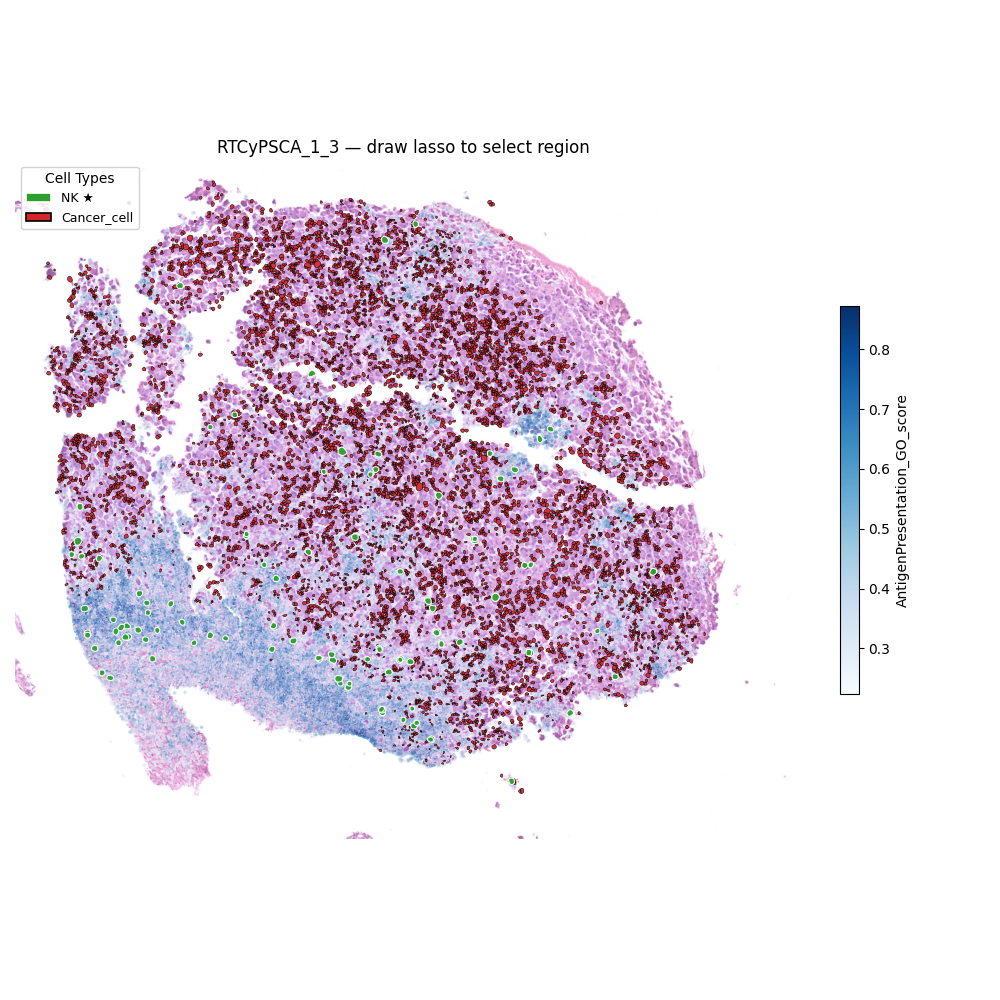

In [146]:
fig1, ax1, a_sub1, coords1, scale1 = plot_tissue_for_selection(
    sdata, adata, tissue_1,
    pathway_1=pathway_1,
    top_quantile=top_quantile,
    cell_type_col=cell_type_col,
    cell_types_to_show=cell_types_to_show,
    he_alpha=he_alpha,
    shrink=shrink,
    highlight_types= highlight_types,      
    highlight_buffer= highlight_size,
    col_1 =    color_scheme
)
plt.show()


In [27]:
# --- Lasso selector for Region 1 ---
# Draw the lasso on the figure above, then run the extraction cell below.
state1 = {"mask": None}

def onselect1(verts):
    path  = MplPath(verts)
    inside = path.contains_points(coords1)
    state1["mask"] = inside
    n = inside.sum()
    ax1.set_title(f"Region 1 ({tissue_1}): {n} cells selected", fontsize=12)
    fig1.canvas.draw_idle()
    print(f"Region 1: {n} cells selected")

lasso1 = LassoSelector(ax1, onselect1, button=[1])
print("Draw lasso on the figure above. Selection stores in state1.")


Draw lasso on the figure above. Selection stores in state1.


In [28]:
assert state1["mask"] is not None, "Draw a lasso on Region 1 first"

label1 = adata.obs.loc[adata.obs["tissue"] == tissue_1, "treatment"].iloc[0]

adata_roi1 = a_sub1[state1["mask"]].copy()
adata_roi1.obs["roi"] = label1
print(f"{label1}: {adata_roi1.n_obs} cells from {tissue_1}")
print(adata_roi1.obs["c2l_permissive"].value_counts())


Region 1: 6381 cells from RTCyPSCA_1_3
c2l_permissive
Cancer_cell          1485
Erythrocyte          1259
N2_like_Neu          1252
Unknown               796
N1_like_Neu           623
M2_like_Mac           258
B                     248
Classical_Mono        168
Endothelial           108
Fibroblast             37
CD8_T                  34
CD4_T                  28
cDC                    28
Treg                   20
NK                     18
NKT                     7
M1_like_Mac             4
pDC                     4
Nonclassical_Mono       3
Intermediate_Mac        1
Name: count, dtype: int64


## Region 2

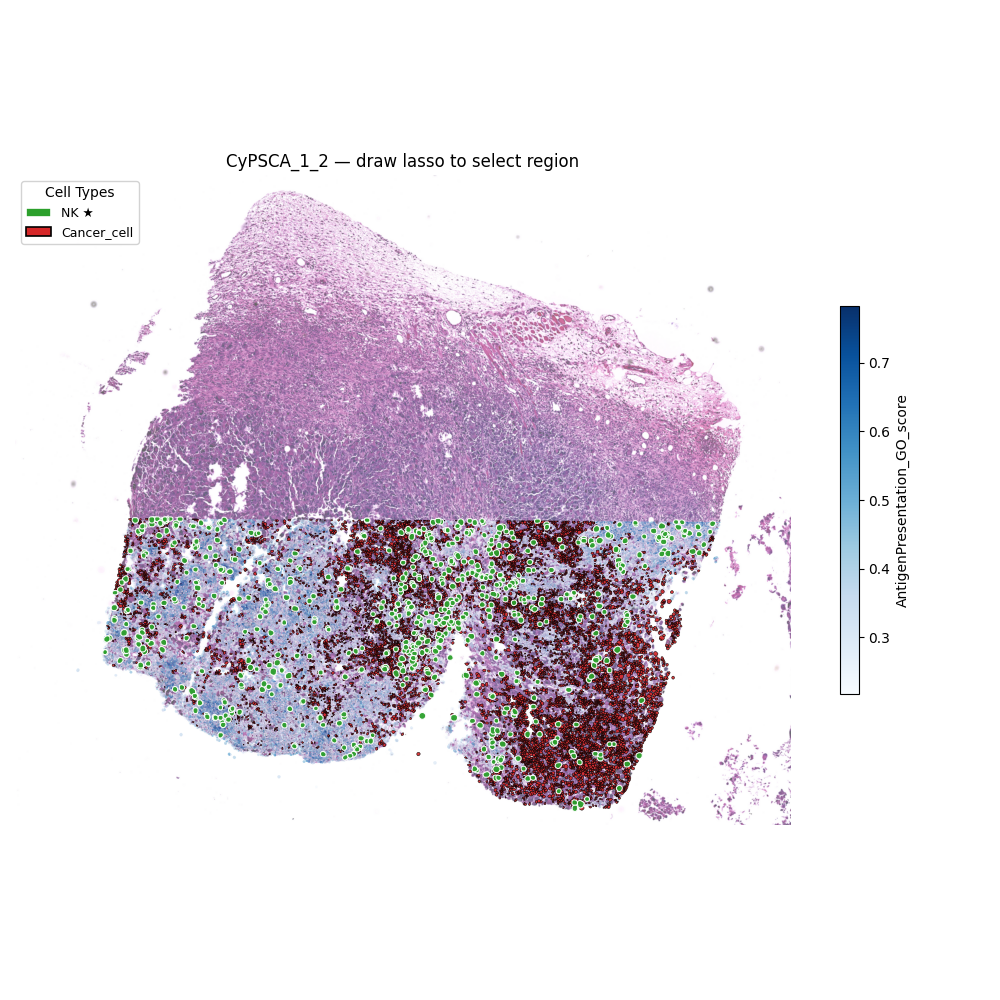

In [147]:
fig2, ax2, a_sub2, coords2, scale2 = plot_tissue_for_selection(
    sdata, adata, tissue_2,
    pathway_1=pathway_1,
    top_quantile=top_quantile,
    cell_type_col=cell_type_col,
    cell_types_to_show=cell_types_to_show,
    he_alpha=he_alpha,
    shrink=shrink,
    highlight_types= highlight_types,      # <-- enlarges highlighted cells specifically
    highlight_buffer= highlight_size,          # <-- how many units to expand by
    col_1= pathway_color[pathway_1]
)
plt.show()

In [40]:
# --- Lasso selector for Region 2 ---
state2 = {"mask": None}

def onselect2(verts):
    path   = MplPath(verts)
    inside = path.contains_points(coords2)
    state2["mask"] = inside
    n = inside.sum()
    ax2.set_title(f"Region 2 ({tissue_2}): {n} cells selected", fontsize=12)
    fig2.canvas.draw_idle()
    print(f"Region 2: {n} cells selected")

lasso2 = LassoSelector(ax2, onselect2, button=[1])
print("Draw lasso on the figure above. Selection stores in state2.")


Draw lasso on the figure above. Selection stores in state2.


In [41]:
assert state2["mask"] is not None, "Draw a lasso on Region 2 first"

label2 = adata.obs.loc[adata.obs["tissue"] == tissue_2, "treatment"].iloc[0]

adata_roi2 = a_sub2[state2["mask"]].copy()
adata_roi2.obs["roi"] = label2
print(f"{label2}: {adata_roi2.n_obs} cells from {tissue_2}")
print(adata_roi2.obs["c2l_permissive"].value_counts())


Region 2: 6193 cells from CyPSCA_1_2
c2l_permissive
Cancer_cell          3004
Erythrocyte           834
Unknown               816
B                     321
N2_like_Neu           298
N1_like_Neu           296
Endothelial           110
CD8_T                 104
CD4_T                  83
Classical_Mono         67
NK                     64
M2_like_Mac            46
Treg                   46
NKT                    36
Fibroblast             24
pDC                    16
cDC                    12
Nonclassical_Mono       9
Intermediate_Mac        7
Name: count, dtype: int64


# Proportional Comparison

Region 1 (RTCyPSCA_1_3) → RTCyPSCA_Tu1
Region 2 (CyPSCA_1_2) → CyPSCA_Tu1


/tmp/ipykernel_2823317/1876234128.py:127: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(2, 2, figsize=(16, 14))


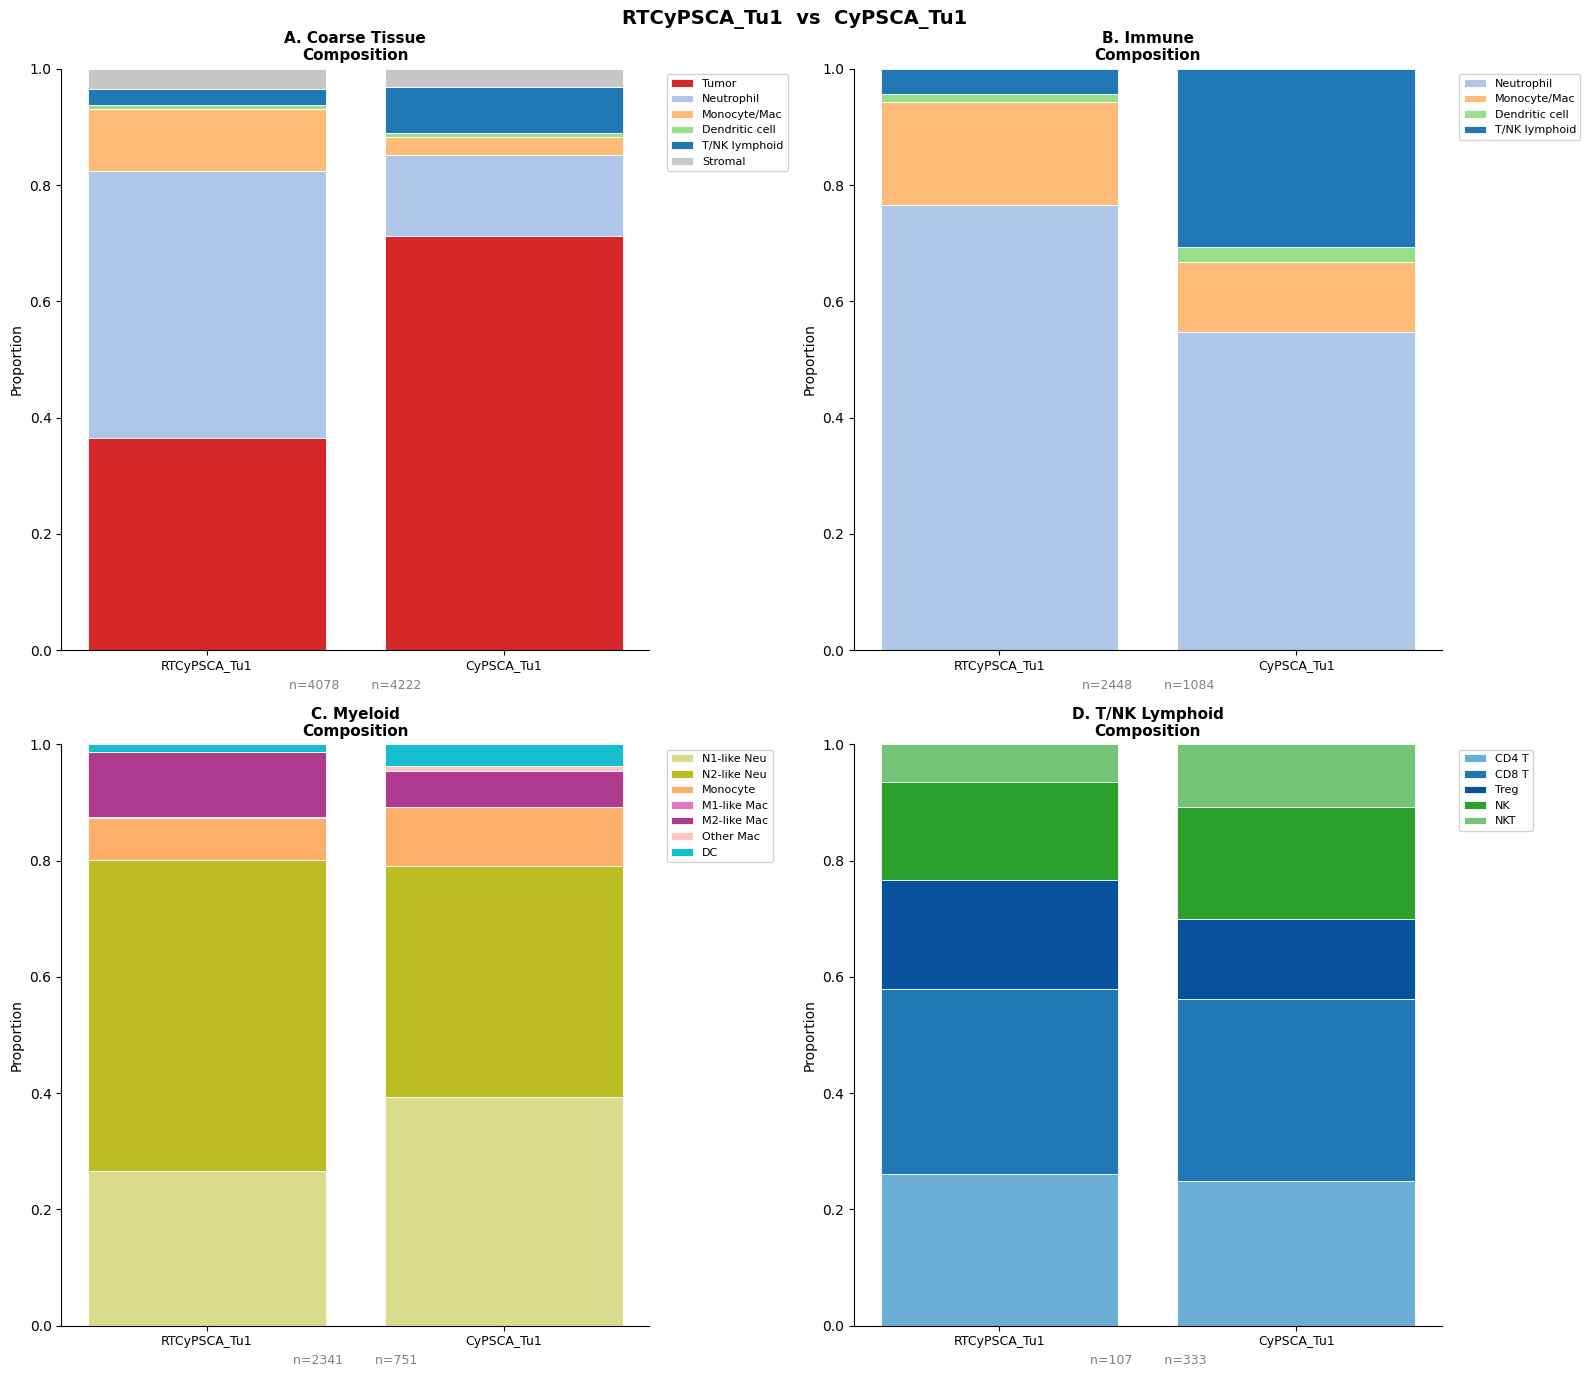


=== A. Coarse ===


,RTCyPSCA_Tu1 (n=4078),CyPSCA_Tu1 (n=4222)
group,,
Tumor,1485 (36.4%),3004 (71.2%)
Neutrophil,1875 (46.0%),594 (14.1%)
Monocyte/Mac,434 (10.6%),129 (3.1%)
Dendritic cell,32 (0.8%),28 (0.7%)
T/NK lymphoid,107 (2.6%),333 (7.9%)
Stromal,145 (3.6%),134 (3.2%)



=== C. Myeloid ===


,RTCyPSCA_Tu1 (n=2341),CyPSCA_Tu1 (n=751)
group,,
N1-like Neu,623 (26.6%),296 (39.4%)
N2-like Neu,1252 (53.5%),298 (39.7%)
Monocyte,171 (7.3%),76 (10.1%)
M1-like Mac,4 (0.2%),0 (0.0%)
M2-like Mac,258 (11.0%),46 (6.1%)
Other Mac,1 (0.0%),7 (0.9%)
DC,32 (1.4%),28 (3.7%)



=== D. T/NK ===


,RTCyPSCA_Tu1 (n=107),CyPSCA_Tu1 (n=333)
group,,
CD4 T,28 (26.2%),83 (24.9%)
CD8 T,34 (31.8%),104 (31.2%)
Treg,20 (18.7%),46 (13.8%)
NK,18 (16.8%),64 (19.2%)
NKT,7 (6.5%),36 (10.8%)


In [44]:
cell_type_col = "c2l_permissive"

EXCLUDE = {"B", "Erythrocyte", "Unknown"}

# label1 / label2 are set by the extract cells above
print(f"{label1} ({tissue_1})  vs  {label2} ({tissue_2})")

# ── Grouping definitions ──────────────────────────────────────────────────────
COARSE_GROUPS = {
    "Tumor":          ["Cancer_cell"],
    "Neutrophil":     ["N1_like_Neu", "N2_like_Neu"],
    "Monocyte/Mac":   ["Classical_Mono", "Nonclassical_Mono", "M1_like_Mac", "M2_like_Mac", "Intermediate_Mac"],
    "Dendritic cell": ["cDC", "pDC"],
    "T/NK lymphoid":  ["CD4_T", "CD8_T", "Treg", "NK", "NKT"],
    "Stromal":        ["Endothelial", "Fibroblast"],
}

IMMUNE_GROUPS = {
    "Neutrophil":     ["N1_like_Neu", "N2_like_Neu"],
    "Monocyte/Mac":   ["Classical_Mono", "Nonclassical_Mono", "M1_like_Mac", "M2_like_Mac", "Intermediate_Mac"],
    "Dendritic cell": ["cDC", "pDC"],
    "T/NK lymphoid":  ["CD4_T", "CD8_T", "Treg", "NK", "NKT"],
}

MYELOID_GROUPS = {
    "N1-like Neu":    ["N1_like_Neu"],
    "N2-like Neu":    ["N2_like_Neu"],
    "Monocyte":       ["Classical_Mono", "Nonclassical_Mono"],
    "M1-like Mac":    ["M1_like_Mac"],
    "M2-like Mac":    ["M2_like_Mac"],
    "Other Mac":      ["Intermediate_Mac"],
    "DC":             ["cDC", "pDC"],
}

TNK_GROUPS = {
    "CD4 T": ["CD4_T"],
    "CD8 T": ["CD8_T"],
    "Treg":  ["Treg"],
    "NK":    ["NK"],
    "NKT":   ["NKT"],
}

# ── Colors ────────────────────────────────────────────────────────────────────
C = CELL_TYPE_COLORS

COARSE_COLORS = {
    "Tumor":          C.get("Cancer_cell",      "#d62728"),
    "Neutrophil":     "#aec7e8",
    "Monocyte/Mac":   "#ffbb78",
    "Dendritic cell": "#98df8a",
    "T/NK lymphoid":  C.get("CD8_T",            "#1f77b4"),
    "Stromal":        "#c7c7c7",
}

IMMUNE_COLORS = {
    "Neutrophil":     "#aec7e8",
    "Monocyte/Mac":   "#ffbb78",
    "Dendritic cell": "#98df8a",
    "T/NK lymphoid":  C.get("CD8_T",            "#1f77b4"),
}

MYELOID_COLORS = {
    "N1-like Neu":    C.get("N1_like_Neu",      "#6baed6"),
    "N2-like Neu":    C.get("N2_like_Neu",      "#c5b0d5"),
    "Monocyte":       C.get("Classical_Mono",   "#fd8d3c"),
    "M1-like Mac":    C.get("M1_like_Mac",      "#de2d26"),
    "M2-like Mac":    C.get("M2_like_Mac",      "#f768a1"),
    "Other Mac":      C.get("Intermediate_Mac", "#c49c94"),
    "DC":             C.get("cDC",              "#74c476"),
}

TNK_COLORS = {
    "CD4 T": C.get("CD4_T", "#aec7e8"),
    "CD8 T": C.get("CD8_T", "#1f77b4"),
    "Treg":  C.get("Treg",  "#9467bd"),
    "NK":    C.get("NK",    "#2ca02c"),
    "NKT":   C.get("NKT",   "#17becf"),
}

# ── Helpers ───────────────────────────────────────────────────────────────────
def compute_props(obs, groups, exclude=None):
    exclude = exclude or set()
    ct_counts = obs[~obs[cell_type_col].isin(exclude)][cell_type_col].value_counts()
    rows = [{"group": g, "count": sum(ct_counts.get(t, 0) for t in types)}
            for g, types in groups.items()]
    df = pd.DataFrame(rows).set_index("group")
    total = df["count"].sum()
    df["proportion"] = df["count"] / total if total > 0 else 0.0
    return df

def plot_stacked_bars(props_r1, props_r2, title, ax, colors, lbl1, lbl2):
    groups = list(props_r1.index)
    bottom1 = bottom2 = 0.0
    for i, group in enumerate(groups):
        color = colors.get(group, f"C{i}")
        v1 = float(props_r1.loc[group, "proportion"])
        v2 = float(props_r2.loc[group, "proportion"])
        kw = dict(color=color, edgecolor="white", linewidth=0.6)
        ax.bar(lbl1, v1, bottom=bottom1, label=group, **kw)
        ax.bar(lbl2, v2, bottom=bottom2, **kw)
        bottom1 += v1
        bottom2 += v2
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_ylim(0, 1.0)
    ax.set_ylabel("Proportion")
    ax.tick_params(axis="x", labelsize=9)
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0),
              fontsize=8, framealpha=0.85)
    ax.spines[["top", "right"]].set_visible(False)

# ── Compute ───────────────────────────────────────────────────────────────────
obs1, obs2 = adata_roi1.obs, adata_roi2.obs

coarse_r1  = compute_props(obs1, COARSE_GROUPS,  exclude=EXCLUDE)
coarse_r2  = compute_props(obs2, COARSE_GROUPS,  exclude=EXCLUDE)
immune_r1  = compute_props(obs1, IMMUNE_GROUPS)
immune_r2  = compute_props(obs2, IMMUNE_GROUPS)
myeloid_r1 = compute_props(obs1, MYELOID_GROUPS)
myeloid_r2 = compute_props(obs2, MYELOID_GROUPS)
tnk_r1     = compute_props(obs1, TNK_GROUPS)
tnk_r2     = compute_props(obs2, TNK_GROUPS)

# ── Plot 2×2 ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axf = axes.flatten()

panels = [
    (coarse_r1,  coarse_r2,  "A. Coarse Tissue\nComposition",  COARSE_COLORS),
    (immune_r1,  immune_r2,  "B. Immune\nComposition",          IMMUNE_COLORS),
    (myeloid_r1, myeloid_r2, "C. Myeloid\nComposition",         MYELOID_COLORS),
    (tnk_r1,     tnk_r2,     "D. T/NK Lymphoid\nComposition",   TNK_COLORS),
]

for ax, (r1, r2, title, colors) in zip(axf, panels):
    plot_stacked_bars(r1, r2, title, ax, colors, label1, label2)
    n1 = int(r1["count"].sum())
    n2 = int(r2["count"].sum())
    ax.set_xlabel(f"n={n1}        n={n2}", fontsize=9, color="gray")

plt.suptitle(f"{label1}  vs  {label2}", fontsize=14, fontweight="bold")
plt.tight_layout()
display(fig)
plt.close(fig)

# ── Summary tables ────────────────────────────────────────────────────────────
for title, r1, r2 in [
    ("A. Coarse",  coarse_r1,  coarse_r2),
    ("C. Myeloid", myeloid_r1, myeloid_r2),
    ("D. T/NK",    tnk_r1,     tnk_r2),
]:
    print(f"\n=== {title} ===")
    display(pd.DataFrame({
        f"{label1} (n={int(r1['count'].sum())})": r1["count"].astype(int).astype(str) + "  (" + (r1["proportion"]*100).round(1).astype(str) + "%)",
        f"{label2} (n={int(r2['count'].sum())})": r2["count"].astype(int).astype(str) + "  (" + (r2["proportion"]*100).round(1).astype(str) + "%)",
    }))


# Differential Expression: Region 1 vs Region 2

In [50]:
import anndata

# Combine both ROIs — align on shared genes only
shared_genes = adata_roi1.var_names.intersection(adata_roi2.var_names)
adata_combined = anndata.concat(
    [adata_roi1[:, shared_genes], adata_roi2[:, shared_genes]],
    label="roi", keys=[label1, label2]
)
adata_combined.obs["roi"] = adata_combined.obs["roi"].astype("category")
print(f"Combined: {adata_combined.n_obs} cells, {adata_combined.n_vars} genes")
print(adata_combined.obs["roi"].value_counts())


Combined: 12574 cells, 19059 genes
roi
RTCyPSCA_Tu1    6381
CyPSCA_Tu1      6193
Name: count, dtype: int64


In [123]:
-log(1.061565e-236)

NameError: name 'log' is not defined

In [51]:
# DE: label1 vs label2 (all cell types pooled)
sc.tl.rank_genes_groups(
    adata_combined,
    groupby="roi",
    groups=[label1],
    reference=label2,
    method="wilcoxon",
    key_added="de_roi",
)

de_df = sc.get.rank_genes_groups_df(adata_combined, group=label1, key="de_roi")
de_df = de_df.sort_values("scores", ascending=False)

print(f"Total DE genes: {len(de_df)}")
print(f"\nTop upregulated in {label1}:")
display(de_df.query("pvals_adj < 0.05 and logfoldchanges > 0.5").head(20))
print(f"\nTop downregulated in {label1} (higher in {label2}):")
display(de_df.query("pvals_adj < 0.05 and logfoldchanges < -0.5").tail(20))


Total DE genes: 19059

Top upregulated in RTCyPSCA_Tu1:


,names,scores,logfoldchanges,pvals,pvals_adj
0,Mmp10,49.021870,2.255419,0.000000e+00,0.000000e+00
1,Ctsl,46.530365,1.270547,0.000000e+00,0.000000e+00
2,S100a6,43.163204,0.780292,0.000000e+00,0.000000e+00
3,Plin2,38.165737,1.713803,0.000000e+00,0.000000e+00
4,Prdx1,37.930809,1.541147,0.000000e+00,0.000000e+00
5,Grem1,37.187019,1.815440,1.106233e-302,2.635462e-299
6,Thbs2,36.421650,1.361097,1.934235e-290,4.096065e-287
7,Selenop,35.083557,1.555657,1.200819e-269,2.288641e-266
8,Tmsb4x,34.745560,0.544196,1.617464e-264,2.802476e-261
9,Psap,33.632618,1.303887,5.598336e-248,8.207591e-245



Top downregulated in RTCyPSCA_Tu1 (higher in CyPSCA_Tu1):


,names,scores,logfoldchanges,pvals,pvals_adj
19036,Tuba1b,-18.189690,-1.022345,6.229254e-74,7.914890e-72
19038,Capg,-18.398026,-0.832591,1.362377e-75,1.778462e-73
19039,Hist1h1e,-18.666145,-1.221212,9.335200e-78,1.289272e-75
19040,Lgals1,-18.968275,-0.782912,3.119772e-80,4.437293e-78
19041,Hist1h2ap,-19.073778,-2.148668,4.170595e-81,6.114412e-79
19042,Atp2a2,-19.155998,-0.613991,8.625671e-82,1.315173e-79
19043,mt-Nd4l,-20.163044,-0.521668,2.067635e-90,3.825928e-88
19044,Anxa1,-20.568003,-0.580343,5.310855e-94,1.100213e-91
19045,Itga6,-20.725206,-0.821854,2.052455e-95,4.445198e-93
19046,Timp1,-20.792118,-0.562503,5.100810e-96,1.117429e-93


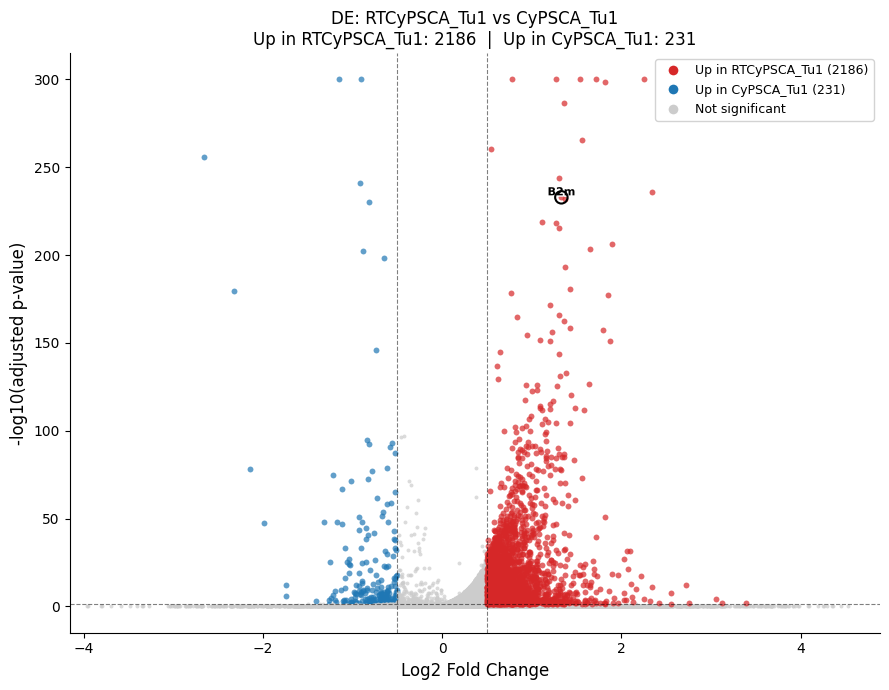

In [124]:
# ── Volcano plot ──────────────────────────────────────────────────────────────
import matplotlib.patheffects as pe

n_label      = 0             # top N significant genes to auto-label (0 = off)
genes_to_label = ["B2m"]   # specific genes to label regardless of rank
lfc_thresh   = 0.5
padj_thresh  = 0.05
xlim_pad     = 1.5           # padding beyond outermost significant gene

df = de_df.copy()
df["neg_log10_padj"] = -np.log10(df["pvals_adj"].clip(lower=1e-300))

# Classify points
df["color"] = "gray"
df.loc[(df["logfoldchanges"] >  lfc_thresh) & (df["pvals_adj"] < padj_thresh), "color"] = "up"
df.loc[(df["logfoldchanges"] < -lfc_thresh) & (df["pvals_adj"] < padj_thresh), "color"] = "down"

# X-axis limits: span of significant genes + padding
sig = df[df["color"] != "gray"]["logfoldchanges"]
x_lo = sig.min() - xlim_pad if len(sig) else -6
x_hi = sig.max() + xlim_pad if len(sig) else  6

color_map = {"up": "#d62728", "down": "#1f77b4", "gray": "#cccccc"}
size_map  = {"up": 18,        "down": 18,         "gray": 8}

fig, ax = plt.subplots(figsize=(9, 7))

for grp, sub in df.groupby("color"):
    ax.scatter(sub["logfoldchanges"], sub["neg_log10_padj"],
               c=color_map[grp], s=size_map[grp], alpha=0.7,
               linewidths=0, rasterized=True)

# Threshold lines
ax.axvline( lfc_thresh,  color="black", lw=0.8, ls="--", alpha=0.5)
ax.axvline(-lfc_thresh,  color="black", lw=0.8, ls="--", alpha=0.5)
ax.axhline(-np.log10(padj_thresh), color="black", lw=0.8, ls="--", alpha=0.5)
ax.set_xlim(x_lo, x_hi)

# Build label set: top N auto + explicit genes
to_label = pd.DataFrame()
if n_label > 0:
    top_up   = df[df["color"] == "up"].nlargest(n_label,  "neg_log10_padj")
    top_down = df[df["color"] == "down"].nlargest(n_label, "neg_log10_padj")
    to_label = pd.concat([top_up, top_down])

if genes_to_label:
    pinned = df[df["names"].isin(genes_to_label)]
    # Draw pinned genes as large outlined circles so they stand out
    ax.scatter(pinned["logfoldchanges"], pinned["neg_log10_padj"],
               s=80, facecolors="none", edgecolors="black", linewidths=1.5, zorder=5)
    to_label = pd.concat([to_label, pinned]).drop_duplicates(subset="names")

for _, row in to_label.iterrows():
    ax.text(row["logfoldchanges"], row["neg_log10_padj"],
            row["names"], fontsize=8, ha="center", va="bottom", fontweight="bold",
            path_effects=[pe.withStroke(linewidth=2, foreground="white")])

n_up   = (df["color"] == "up").sum()
n_down = (df["color"] == "down").sum()

ax.set_xlabel("Log2 Fold Change", fontsize=12)
ax.set_ylabel("-log10(adjusted p-value)", fontsize=12)
ax.set_title(f"DE: {label1} vs {label2}\n"
             f"Up in {label1}: {n_up}  |  Up in {label2}: {n_down}", fontsize=12)
ax.legend(
    handles=[
        plt.Line2D([0],[0], marker="o", color="w", markerfacecolor="#d62728", markersize=8, label=f"Up in {label1} ({n_up})"),
        plt.Line2D([0],[0], marker="o", color="w", markerfacecolor="#1f77b4", markersize=8, label=f"Up in {label2} ({n_down})"),
        plt.Line2D([0],[0], marker="o", color="w", markerfacecolor="#cccccc", markersize=8, label="Not significant"),
    ],
    fontsize=9, framealpha=0.85
)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
display(fig)
plt.close(fig)


In [62]:
# Optional: DE per cell type (only cell types present in both ROIs)
cell_type_col = "c2l_permissive"

ct_roi1 = set(adata_roi1.obs[cell_type_col].unique())
ct_roi2 = set(adata_roi2.obs[cell_type_col].unique())
shared_cts = sorted(ct_roi1 & ct_roi2)
print(f"Cell types present in both ROIs: {shared_cts}")

de_per_ct = {}
for ct in shared_cts:
    sub = adata_combined[adata_combined.obs[cell_type_col] == ct].copy()
    if sub.obs["roi"].nunique() < 2:
        continue
    n1 = (sub.obs["roi"] == label1).sum()
    n2 = (sub.obs["roi"] == label2).sum()
    if n1 < 3 or n2 < 3:
        print(f"Skipping {ct} — too few cells ({label1}={n1}, {label2}={n2})")
        continue
    sc.tl.rank_genes_groups(sub, groupby="roi", groups=[label1],
                             reference=label2, method="wilcoxon",
                             key_added="de_ct")
    df = sc.get.rank_genes_groups_df(sub, group=label1, key="de_ct")
    de_per_ct[ct] = df.sort_values("scores", ascending=False)
    print(f"{ct}: {(df.pvals_adj < 0.05).sum()} significant DE genes")


Cell types present in both ROIs: ['B', 'CD4_T', 'CD8_T', 'Cancer_cell', 'Classical_Mono', 'Endothelial', 'Erythrocyte', 'Fibroblast', 'Intermediate_Mac', 'M2_like_Mac', 'N1_like_Neu', 'N2_like_Neu', 'NK', 'NKT', 'Nonclassical_Mono', 'Treg', 'Unknown', 'cDC', 'pDC']
B: 657 significant DE genes
CD4_T: 3 significant DE genes
CD8_T: 3 significant DE genes
Cancer_cell: 2393 significant DE genes
Classical_Mono: 10 significant DE genes
Endothelial: 43 significant DE genes
Erythrocyte: 2367 significant DE genes
Fibroblast: 0 significant DE genes
Skipping Intermediate_Mac — too few cells (RTCyPSCA_Tu1=1, CyPSCA_Tu1=7)
M2_like_Mac: 29 significant DE genes
N1_like_Neu: 674 significant DE genes
N2_like_Neu: 1583 significant DE genes
NK: 0 significant DE genes
NKT: 0 significant DE genes
Nonclassical_Mono: 0 significant DE genes
Treg: 0 significant DE genes
Unknown: 482 significant DE genes
cDC: 0 significant DE genes
pDC: 0 significant DE genes


# Enrichment Analysis

In [65]:
# Enrichment on pooled DE (Region 1 upregulated genes)
databases = [
    "KEGG_2019_Mouse",
    "GO_Biological_Process_2023",
    "GO_Molecular_Function_2023",
]

up_genes = (
    de_df
    .query("pvals_adj < 0.05 and logfoldchanges > 0.5")
    .head(300)["names"]
    .tolist()
)
down_genes = (
    de_df
    .query("pvals_adj < 0.05 and logfoldchanges < -0.5")
    .tail(300)["names"]
    .tolist()
)

print(f"Upregulated genes for enrichment: {len(up_genes)}")
print(f"Downregulated genes for enrichment: {len(down_genes)}")

enr_up   = gp.enrichr(gene_list=up_genes,   gene_sets=databases, organism="mouse", outdir=None)
enr_down = gp.enrichr(gene_list=down_genes, gene_sets=databases, organism="mouse", outdir=None)


Upregulated genes for enrichment: 300
Downregulated genes for enrichment: 231


In [66]:
# Summary of enrichment results
for lbl, enr in [(f"{label1} UP", enr_up), (f"{label1} DOWN", enr_down)]:
    sig = enr.results[enr.results["Adjusted P-value"] < 0.05].sort_values("Adjusted P-value")
    print(f"\n=== {lbl} ({len(sig)} significant terms) ===")
    print(sig[["Gene_set", "Term", "Overlap", "Adjusted P-value"]].head(15).to_string(index=False))



=== RTCyPSCA_Tu1 UP (223 significant terms) ===
                  Gene_set                                                                                           Term Overlap  Adjusted P-value
           KEGG_2019_Mouse                                                                                       Lysosome  18/124      1.023926e-10
           KEGG_2019_Mouse                                                                                      Phagosome  17/180      2.303628e-07
GO_Biological_Process_2023                                                  Regulation Of Peptidase Activity (GO:0052547)    9/27      2.846290e-07
           KEGG_2019_Mouse                                                                                   Tuberculosis  15/178      6.150767e-06
           KEGG_2019_Mouse                                                            Antigen processing and presentation   11/90      6.150767e-06
           KEGG_2019_Mouse                                     

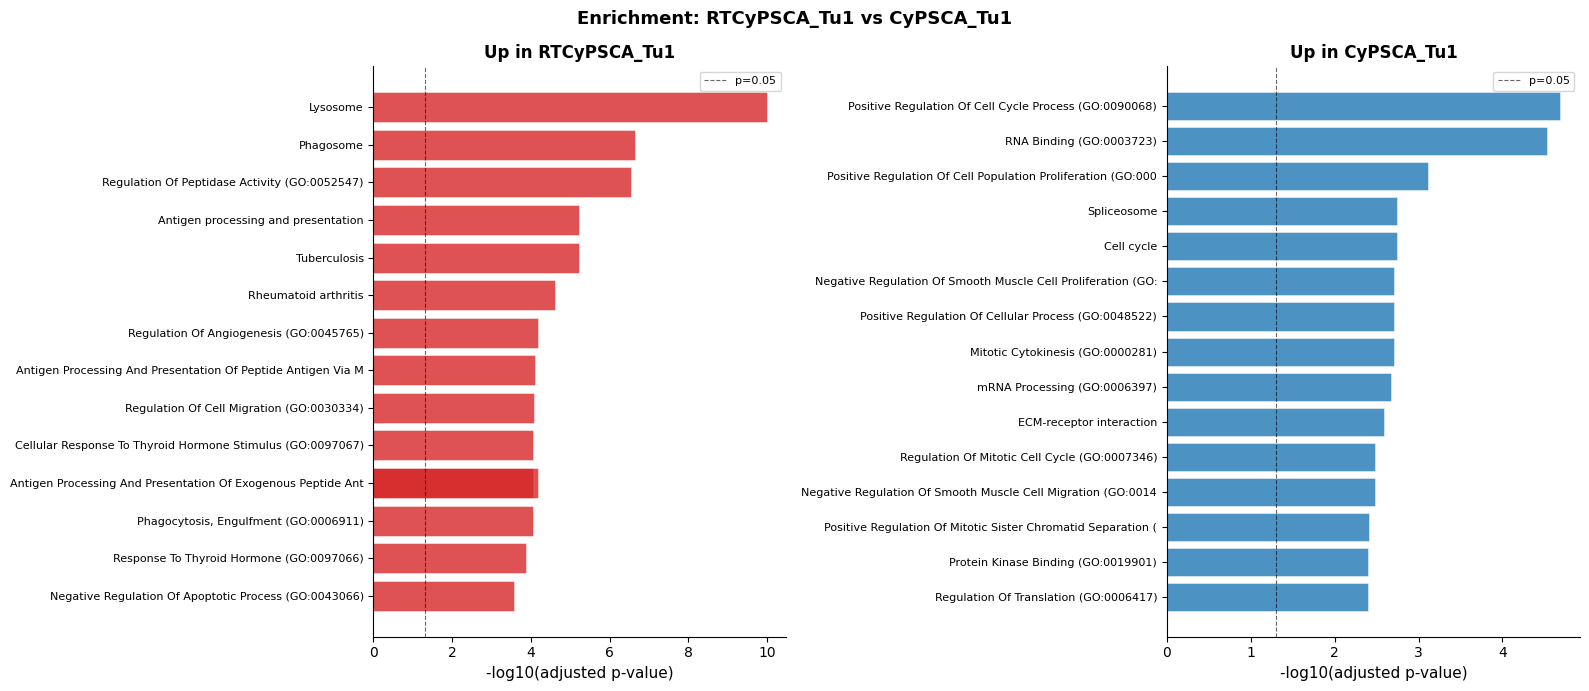

In [127]:
# ── Enrichment bar plot: top up & down pathways ───────────────────────────────
n_terms  = 15   # top terms to show per direction
gene_set_filter = None   # e.g. "GO_Biological_Process_2023" to show one db only

def prep_enrich(enr_result, n, gene_set_filter=None):
    df = enr_result.results.copy()
    if gene_set_filter:
        df = df[df["Gene_set"] == gene_set_filter]
    df = df[df["Adjusted P-value"] < 0.05].copy()
    df["-log10_padj"] = -np.log10(df["Adjusted P-value"].clip(lower=1e-300))
    df["Term_label"] = df["Term"].str.replace("_", " ").str[:60]
    return df.nsmallest(n, "Adjusted P-value").reset_index(drop=True)

up_plot   = prep_enrich(enr_up,   n_terms, gene_set_filter)
down_plot = prep_enrich(enr_down, n_terms, gene_set_filter)

if up_plot.empty and down_plot.empty:
    print("No significant enrichment terms to plot.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    for ax, df_plot, color, direction, lbl in [
        (axes[0], up_plot,   "#d62728", "UP",   f"Up in {label1}"),
        (axes[1], down_plot, "#1f77b4", "DOWN", f"Up in {label2}"),
    ]:
        if df_plot.empty:
            ax.text(0.5, 0.5, "No significant terms", ha="center", va="center",
                    transform=ax.transAxes, fontsize=12, color="gray")
            ax.set_title(lbl, fontsize=12, fontweight="bold")
            ax.axis("off")
            continue

        df_plot = df_plot.sort_values("-log10_padj")
        bars = ax.barh(df_plot["Term_label"], df_plot["-log10_padj"],
                       color=color, alpha=0.8, edgecolor="white", linewidth=0.4)
        ax.axvline(-np.log10(0.05), color="black", lw=0.8, ls="--", alpha=0.6,
                   label="p=0.05")
        ax.set_xlabel("-log10(adjusted p-value)", fontsize=11)
        ax.set_title(lbl, fontsize=12, fontweight="bold")
        ax.tick_params(axis="y", labelsize=8)
        ax.legend(fontsize=8)
        ax.spines[["top", "right"]].set_visible(False)

    plt.suptitle(f"Enrichment: {label1} vs {label2}", fontsize=13, fontweight="bold")
    plt.tight_layout()
    display(fig)
    plt.close(fig)


In [138]:
# Enrichment per cell type — both up (label1) and down (label2) directions
# Re-running this cell safely skips already-completed cell types.
import time

if "enr_per_ct" not in dir():
    enr_per_ct = {}

def safe_enrichr(gene_list, databases, retries=3, delay=5):
    for attempt in range(retries):
        try:
            result = gp.enrichr(gene_list=gene_list, gene_sets=databases,
                                 organism="mouse", outdir=None)
            time.sleep(1)   # polite pause between calls
            return result.results
        except Exception as e:
            if "429" in str(e) or "status code" in str(e).lower():
                wait = delay * (attempt + 1)
                print(f"    Rate limited — waiting {wait}s before retry {attempt+1}/{retries}...")
                time.sleep(wait)
            else:
                raise
    print(f"    Failed after {retries} retries — skipping")
    return None

for ct, df in de_per_ct.items():
    up_genes   = df.query("pvals_adj < 0.05 and logfoldchanges >  0.5").head(200)["names"].tolist()
    down_genes = df.query("pvals_adj < 0.05 and logfoldchanges < -0.5").head(200)["names"].tolist()

    if len(up_genes) < 5 and len(down_genes) < 5:
        print(f"Skipping {ct} — too few markers in either direction")
        continue

    # Check what still needs to be done
    already = enr_per_ct.get(ct, {})
    needs_up   = len(up_genes)   >= 5 and "up"   not in already
    needs_down = len(down_genes) >= 5 and "down" not in already

    if not needs_up and not needs_down:
        print(f"  {ct}: already done — skipping")
        continue

    if ct not in enr_per_ct:
        enr_per_ct[ct] = {}

    if needs_up:
        print(f"  {ct}: enrichment UP ({len(up_genes)} genes)...")
        result = safe_enrichr(up_genes, databases)
        if result is not None:
            enr_per_ct[ct]["up"] = result

    if needs_down:
        print(f"  {ct}: enrichment DOWN ({len(down_genes)} genes)...")
        result = safe_enrichr(down_genes, databases)
        if result is not None:
            enr_per_ct[ct]["down"] = result

print(f"\nDone. Cell types with enrichment results: {list(enr_per_ct.keys())}")


  B: already done — skipping
Skipping CD4_T — too few markers in either direction
Skipping CD8_T — too few markers in either direction
  Cancer_cell: already done — skipping
  Classical_Mono: already done — skipping
  Endothelial: already done — skipping
  Erythrocyte: already done — skipping
Skipping Fibroblast — too few markers in either direction
  M2_like_Mac: enrichment DOWN (8 genes)...
  N1_like_Neu: enrichment UP (200 genes)...
  N1_like_Neu: enrichment DOWN (45 genes)...
  N2_like_Neu: enrichment UP (200 genes)...
  N2_like_Neu: enrichment DOWN (58 genes)...
Skipping NK — too few markers in either direction
Skipping NKT — too few markers in either direction
Skipping Nonclassical_Mono — too few markers in either direction
Skipping Treg — too few markers in either direction
  Unknown: enrichment UP (200 genes)...
  Unknown: enrichment DOWN (20 genes)...
Skipping cDC — too few markers in either direction
Skipping pDC — too few markers in either direction

Done. Cell types with en

Available cell types: ['B', 'Cancer_cell', 'Classical_Mono', 'Endothelial', 'Erythrocyte', 'M2_like_Mac', 'N1_like_Neu', 'N2_like_Neu', 'Unknown']


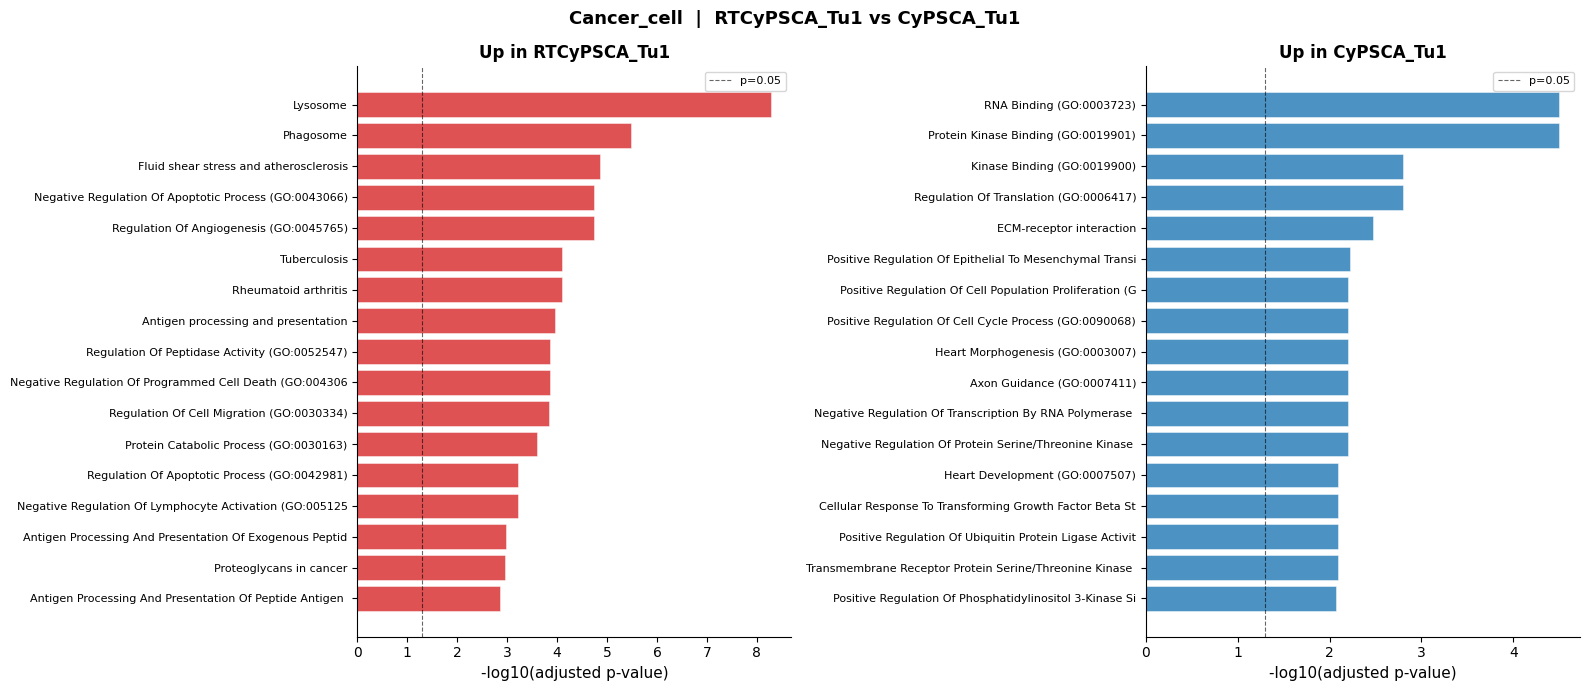

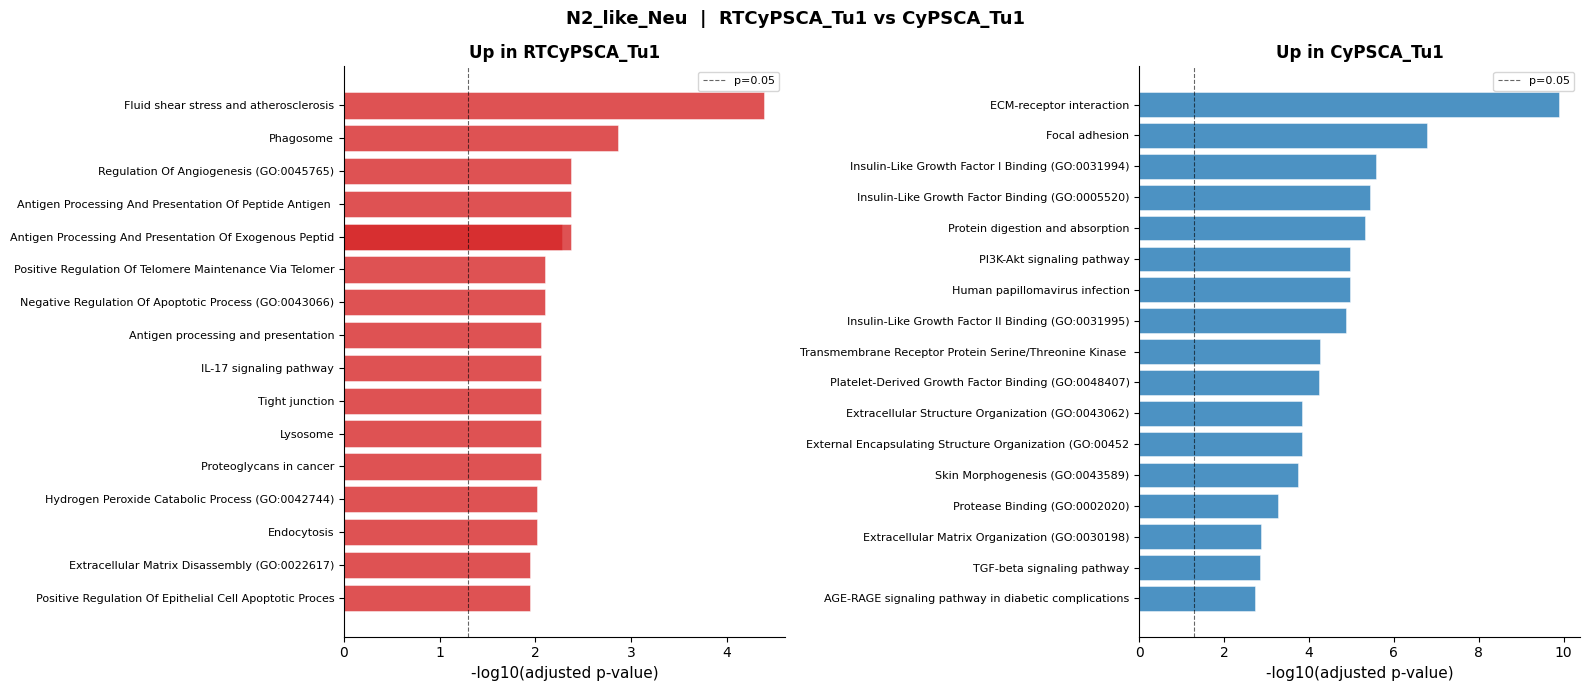

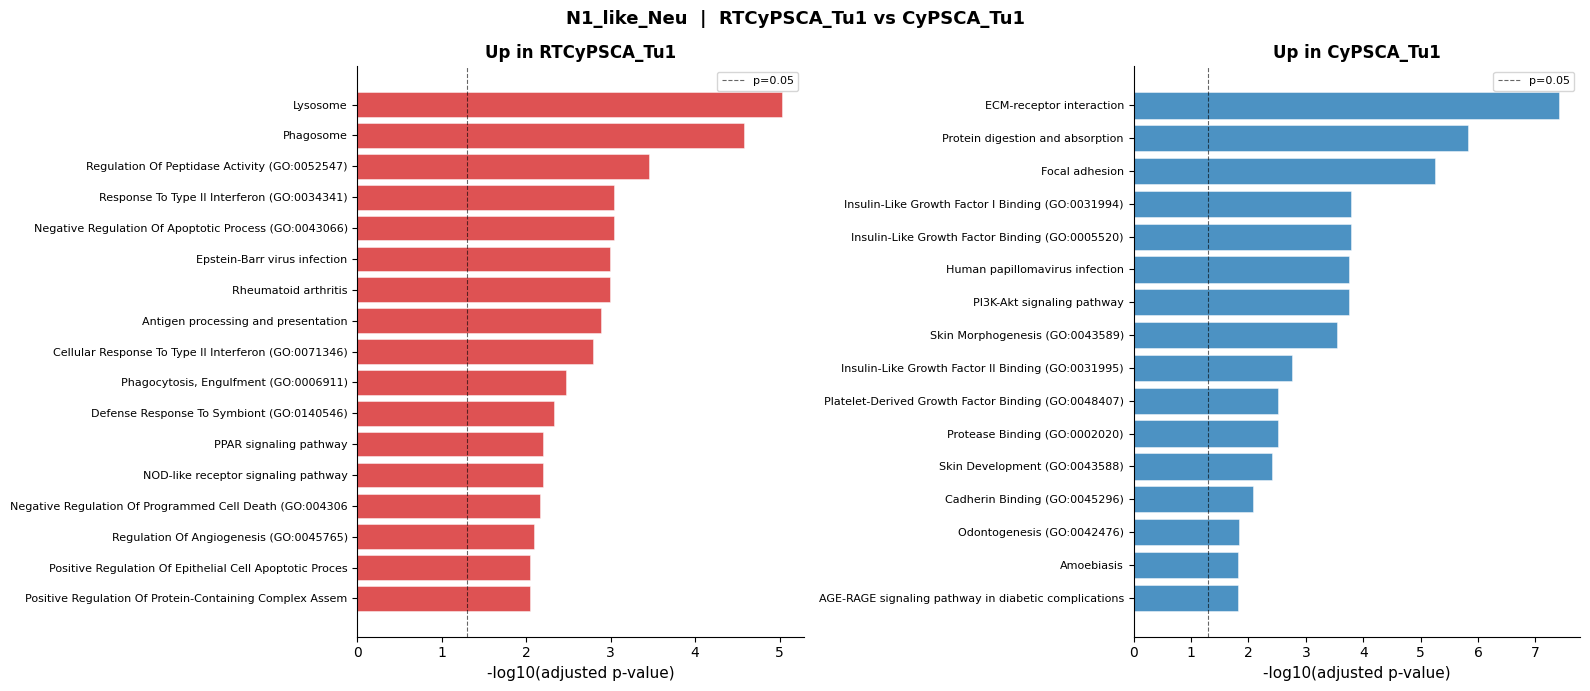

In [149]:
# ── Per-cell-type enrichment: one up/down figure per selected cell type ───────
cell_types_to_plot = ["Cancer_cell", "N2_like_Neu", "N1_like_Neu"]

n_terms         = 17    # top terms per panel
gene_set_filter = None  # e.g. "GO_Biological_Process_2023"

print(f"Available cell types: {list(enr_per_ct.keys())}")

def prep_enrich(results_df, n, gene_set_filter=None):
    df = results_df.copy()
    if gene_set_filter:
        df = df[df["Gene_set"] == gene_set_filter]
    df = df[df["Adjusted P-value"] < 0.05].copy()
    if df.empty:
        return df
    df["-log10_padj"] = -np.log10(df["Adjusted P-value"].clip(lower=1e-300))
    df["Term_label"]  = df["Term"].str.replace("_", " ").str[:55]
    return df.nsmallest(n, "Adjusted P-value").sort_values("-log10_padj")

for ct in cell_types_to_plot:
    if ct not in enr_per_ct:
        print(f"No enrichment results for {ct} — skipping")
        continue

    up_plot   = prep_enrich(enr_per_ct[ct].get("up",   pd.DataFrame()), n_terms, gene_set_filter)
    down_plot = prep_enrich(enr_per_ct[ct].get("down", pd.DataFrame()), n_terms, gene_set_filter)

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    for ax, df_plot, color, lbl in [
        (axes[0], up_plot,   "#d62728", f"Up in {label1}"),
        (axes[1], down_plot, "#1f77b4", f"Up in {label2}"),
    ]:
        if df_plot.empty:
            ax.text(0.5, 0.5, "No significant terms",
                    ha="center", va="center", transform=ax.transAxes,
                    fontsize=12, color="gray")
            ax.set_title(lbl, fontsize=12, fontweight="bold")
            ax.axis("off")
            continue

        ax.barh(df_plot["Term_label"], df_plot["-log10_padj"],
                color=color, alpha=0.8, edgecolor="white", linewidth=0.4)
        ax.axvline(-np.log10(0.05), color="black", lw=0.8, ls="--",
                   alpha=0.6, label="p=0.05")
        ax.set_xlabel("-log10(adjusted p-value)", fontsize=11)
        ax.set_title(lbl, fontsize=12, fontweight="bold")
        ax.tick_params(axis="y", labelsize=8)
        ax.legend(fontsize=8)
        ax.spines[["top", "right"]].set_visible(False)

    plt.suptitle(f"{ct}  |  {label1} vs {label2}",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    display(fig)
    plt.close(fig)


# Save Results

In [ ]:
out_dir = project_dir / "results/region_comparison"
out_dir.mkdir(parents=True, exist_ok=True)

# DE results
de_df.to_csv(out_dir / f"{tissue_1}_vs_{tissue_2}_DE_pooled.csv", index=False)
for ct, df in de_per_ct.items():
    df.to_csv(out_dir / f"{tissue_1}_vs_{tissue_2}_DE_{ct}.csv", index=False)

# Enrichment
enr_up.results.to_csv(out_dir / f"{tissue_1}_vs_{tissue_2}_enrichr_up.csv", index=False)
enr_down.results.to_csv(out_dir / f"{tissue_1}_vs_{tissue_2}_enrichr_down.csv", index=False)
for ct, df in enr_per_ct.items():
    df.to_csv(out_dir / f"{tissue_1}_vs_{tissue_2}_enrichr_{ct}.csv", index=False)

print(f"Saved all results to {out_dir}")


# Delete figures

In [ ]:
import matplotlib.pyplot as plt
print(plt.get_fignums())  # list of currently open figure numbers
plt.close('all')
print(plt.get_fignums())  # list of currently open figure numbers
